# 用于手写数字识别的神经网络（多类别）
在本练习中，你将使用神经网络来识别手写数字0 - 9。

# 大纲
- [1 - 导入包 ](#1)
- [2 - ReLU激活函数](#2)
- [3 -  Softmax函数](#3)
  - [练习1](#ex01)
- [4 - 神经网络](#4)
  - [4.1 问题描述](#4.1)
  - [4.2 数据集](#4.2)
  - [4.3 模型表示](#4.3)
  - [4.4 TensorFlow模型实现](#4.4)
  - [4.5 Softmax函数的位置](#4.5)
    - [练习2](#ex02)

<a name="1"></a>
## 1 - 软件包
首先，让我们运行下面的代码块，导入本次作业中所需的所有软件包。
- [numpy](https://numpy.org/) 是Python进行科学计算的基础软件包。
- [matplotlib](http://matplotlib.org) 是Python中常用的绘图库。
- [tensorflow](https://www.tensorflow.org/) 是一个流行的机器学习平台。

In [1]:
import numpy as np
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from keras.activations import linear, relu, sigmoid
%matplotlib widget
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

from public_tests import * 

from autils import *
from lab_utils_softmax import plt_softmax
np.set_printoptions(precision=2)

<a name="2"></a>
## 2 - ReLU 激活函数
本周，引入了一种新的激活函数，即修正线性单元（ReLU）。
$$ a = max(0,z) $$

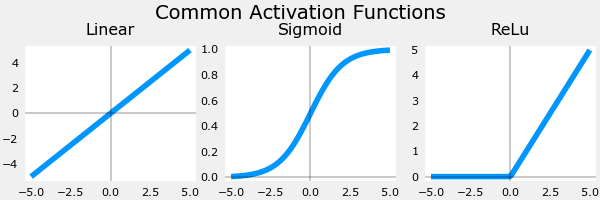

In [2]:
plt_act_trio()

<img align="right" src="./images/C2_W2_ReLu.png"     style=" width:380px; padding: 10px 20px; " >
右边讲座中的示例展示了ReLU的一种应用。在这个示例中，派生的 “品牌感知度” 特征不是二进制的，而是具有连续的值范围。Sigmoid函数最适用于开/关或二进制情况。ReLU提供了一种连续的线性关系。此外，它有一个 “关闭” 范围，在该范围内输出为零。    

“关闭” 特征使ReLU成为一种非线性激活函数。为什么需要这样呢？这使得多个单元能够对最终函数做出贡献而互不干扰。在辅助选修实验中会对此进行更深入的探讨。 

<a name="3"></a>
## 3 -  Softmax函数
多分类神经网络会生成N个输出。其中一个输出会被选作预测答案。在输出层，线性函数会生成一个向量 $\mathbf{z}$，该向量会被输入到Softmax函数中。Softmax函数会将 $\mathbf{z}$ 转换为如下所述的概率分布。应用Softmax函数后，每个输出值都将介于0到1之间，且所有输出值的总和为1。这些输出值可以被理解为概率。Softmax函数的输入值越大，对应的输出概率就越大。 
<center>  <img  src="./images/C2_W2_NNSoftmax.PNG" width="600" />  

softmax函数可以写成：
$$a_j = \frac{e^{z_j}}{ \sum_{k=0}^{N-1}{e^{z_k} }} \tag{1}$$

其中$z = \mathbf{w} \cdot \mathbf{x} + b$，且$N$是输出层中的特征/类别数量。

<a name="ex01"></a>
### Exercise 1
让我们创建一个NumPy实现：

In [3]:
# UNQ_C1
# GRADED CELL: my_softmax

def my_softmax(z):  
    """ Softmax converts a vector of values to a probability distribution.
    Args:
      z (ndarray (N,))  : input data, N features
    Returns:
      a (ndarray (N,))  : softmax of z
    """    
    ### START CODE HERE ### 
    N = len(z)
    a = np.zeros(N)
    ez_sum = 0
    for k in range(N):
        ez_sum = ez_sum + np.exp(z[k])
    for j in range(N):
        a[j] = np.exp(z[j])/ez_sum
    ### END CODE HERE ### 
    return a

In [4]:
z = np.array([1., 2., 3., 4.])
a = my_softmax(z)
atf = tf.nn.softmax(z)
print(f"my_softmax(z):         {a}")
print(f"tensorflow softmax(z): {atf}")

# BEGIN UNIT TEST  
test_my_softmax(my_softmax)
# END UNIT TEST  

my_softmax(z):         [0.03 0.09 0.24 0.64]
tensorflow softmax(z): [0.03 0.09 0.24 0.64]
 All tests passed.


<details>
  <summary><font size="3" color="darkgreen"><b>Click for hints</b></font></summary>
    One implementation uses for loop to first build the denominator and then a second loop to calculate each output.
    
```python
def my_softmax(z):  
    N = len(z)
    a =                     # initialize a to zeros 
    ez_sum =                # initialize sum to zero
    for k in range(N):      # loop over number of outputs             
        ez_sum +=           # sum exp(z[k]) to build the shared denominator      
    for j in range(N):      # loop over number of outputs again                
        a[j] =              # divide each the exp of each output by the denominator   
    return(a)
```
<details>
  <summary><font size="3" color="darkgreen"><b>Click for code</b></font></summary>
   
```python
def my_softmax(z):  
    N = len(z)
    a = np.zeros(N)
    ez_sum = 0
    for k in range(N):                
        ez_sum += np.exp(z[k])       
    for j in range(N):                
        a[j] = np.exp(z[j])/ez_sum   
    return(a)

Or, a vector implementation:

def my_softmax(z):  
    ez = np.exp(z)              
    a = ez/np.sum(ez)           
    return(a)

```


下面，改变 `z` 输入的值。尤其要注意分子中的指数是如何放大这些值的微小差异的。还要注意，输出值的总和为1。

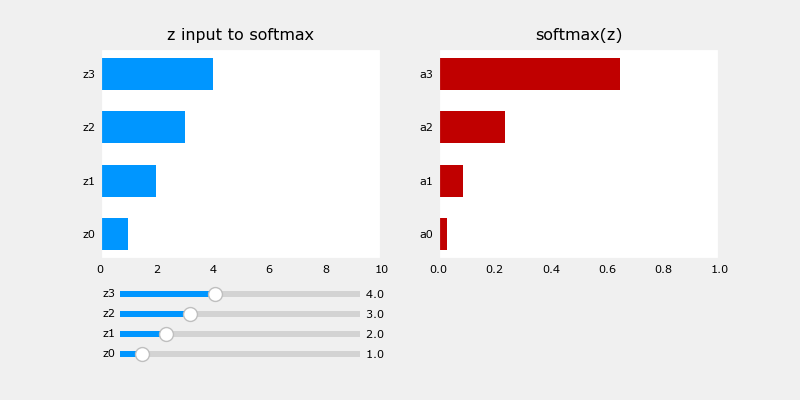

In [5]:
plt.close("all")
plt_softmax(my_softmax)

<a name="4"></a>
## 4 - 神经网络

在上周的作业中，你实现了一个用于二分类的神经网络。本周，你将把它扩展到多分类。这将用到softmax激活函数。


<a name="4.1"></a>
### 4.1 问题陈述

在本练习中，你将使用神经网络识别十个手写数字，即0到9。这是一个多分类任务，需要从n个选项中选择一个。如今，自动手写数字识别应用广泛，从识别邮件信封上的邮政编码到识别银行支票上书写的金额。 


<a name="4.2"></a>
### 4.2 数据集
你将从加载此任务的数据集开始。    
- 如下所示的`load_data()`函数会将数据加载到变量`X`和`y`中。

- 该数据集包含5000个手写数字的训练样本$^1$。  
    - 每个训练样本是一个20像素×20像素的数字灰度图像。  
        - 每个像素由一个浮点数表示，该浮点数指示该位置的灰度强度。  
        - 20×20的像素网格被“展开”成一个400维向量。  
        - 每个训练样本成为我们数据矩阵`X`中的单行。  
        - 这就得到了一个5000×400的矩阵`X`，其中每行都是一个手写数字图像的训练样本。


$$X = 
\left(\begin{array}{cc} 
--- (x^{(1)}) --- \\
--- (x^{(2)}) --- \\
\vdots \\ 
--- (x^{(m)}) --- 
\end{array}\right)$$ 

- 训练集的第二部分是一个5000×1维的向量`y`，它包含训练集的标签。
    - 如果图像是数字`0`，则`y = 0`；如果图像是数字`4`，则`y = 4`，依此类推。

$^1$<sub>这是MNIST手写数字数据集的一个子集 (http://yann.lecun.com/exdb/mnist/)</sub>

In [6]:
# load dataset
X, y = load_data()

#### 4.2.1 查看变量
让我们更加熟悉你的数据集。 
- 一个好的开始方式是打印出每个变量，看看它包含什么。

下面的代码打印变量`X`和`y`中的第一个元素。

In [7]:
print ('The first element of X is: ', X[0])

The first element of X is:  [ 0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  8.56e-06  1.94e-06 -7.37e-04
 -8.13e-03 -1.86e-02 -1.87e-02 -1.88e-02 -1.91e-02 -1.64e-02 -3.78e-03
  3.30e-04  1.28e-05  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  1.16e-04  1.20e-04 -1.40e-02 -2.85e-02  8.04e-02
  2.67e-01  2.74e-01  2.79e-01  2.74e-01  2.25e-0

In [8]:
print ('The first element of y is: ', y[0,0])
print ('The last element of y is: ', y[-1,0])

The first element of y is:  0
The last element of y is:  9


#### 4.2.2 检查变量的维度
熟悉数据的另一种方法是查看其维度。请打印 `X` 和 `y` 的形状，了解数据集中有多少个训练样本。

In [9]:
print ('The shape of X is: ' + str(X.shape))
print ('The shape of y is: ' + str(y.shape))

The shape of X is: (5000, 400)
The shape of y is: (5000, 1)


#### 4.2.3 数据可视化
你将从可视化训练集的一个子集开始。
- 在下面的代码单元格中，代码从“X”中随机选择64行，将每行映射回一个20像素×20像素的灰度图像，并将这些图像一起显示。
- 每张图像的标签显示在图像上方。

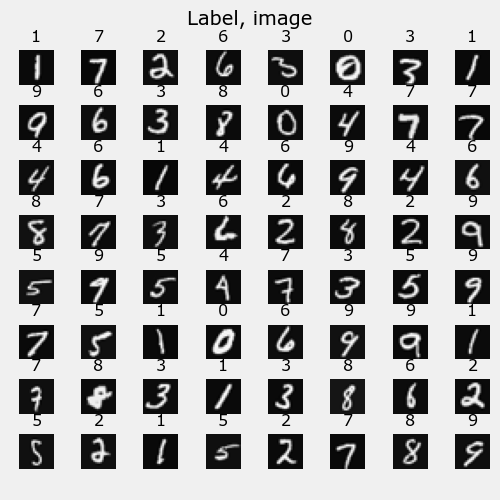

In [10]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# You do not need to modify anything in this cell

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(5,5))
fig.tight_layout(pad=0.13,rect=[0, 0.03, 1, 0.91]) #[left, bottom, right, top]

#fig.tight_layout(pad=0.5)
widgvis(fig)
for i,ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)
    
    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X[random_index].reshape((20,20)).T
    
    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')
    
    # Display the label above the image
    ax.set_title(y[random_index,0])
    ax.set_axis_off()
    fig.suptitle("Label, image", fontsize=14)

<a name="4.3"></a>
### 4.3 模型表示
在本次作业中，你将使用的神经网络如下图所示。
- 该网络有两个具有ReLU激活函数的全连接层，之后是一个具有线性激活函数的输出层。
  - 请记住，我们的输入是数字图像的像素值。
  - 由于图像大小为20×20，因此我们有400个输入。 
    
<img src="images/C2_W2_Assigment_NN.png" width="600" height="200">

- 这些参数的维度是为一个神经网络设定的，该神经网络第1层有$25$个单元，第2层有$15$个单元，第3层有$10$个输出单元，每个输出单元对应一个数字。    
    - 回想一下，这些参数的维度是这样确定的：
        - 如果网络某一层有$s_{in}$个单元，下一层有$s_{out}$个单元，那么
            - $W$的维度将是$s_{in} \times s_{out}$。
            - $b$将是一个有$s_{out}$个元素的向量。
      - 因此，`W`和`b`的形状是：
        - 第一层：`W1`的形状是(400, 25)，`b1`的形状是(25,)。
        - 第二层：`W2`的形状是(25, 15)，`b2`的形状是：(15,)。
        - 第三层：`W3`的形状是(15, 10)，`b3`的形状是：(10,)。
**注意**：偏置向量`b`可以表示为一维(n,)或二维(n,1)数组。TensorFlow采用一维表示，本实验也将遵循这一惯例。
               

<a name="4.4"></a>
### 4.4 TensorFlow模型实现

TensorFlow模型是逐层构建的。系统会为您计算某一层的输入维度（如上文的$s_{in}$）。您需指定某一层的*输出维度*，这将决定下一层的输入维度。第一层的输入维度由下面`model.fit`语句中指定的输入数据大小得出。
>**注意**：也可以添加一个输入层来指定第一层的输入维度。例如：
`tf.keras.Input(shape=(400,)),    #指定输入形状`
我们在此处提及这一点，以说明一些模型尺寸设定的问题。 

### 4.5 Softmax的位置
如课程及可选的Softmax实验中所述，在训练过程中，如果将Softmax与损失函数归为一组，而不是与输出层归为一组，数值稳定性会得到提高。这在**构建**模型和**使用**模型时会产生影响。   
构建模型：
* 最后一个全连接层（Dense layer）应使用“线性”激活函数。这实际上等同于无激活函数。
* `model.compile`语句将通过包含`from_logits=True`来表明这一点。`loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)` 
* 这不会影响目标的形式。在使用稀疏分类交叉熵（SparseCategorialCrossentropy）的情况下，目标是预期的数字，0到9。

使用模型：
* 输出不是概率。如果需要输出概率，则应用Softmax函数。 

<a name="ex02"></a>
### Exercise 2

下面，使用Keras的[顺序模型](https://keras.io/guides/sequential_model/)和带有ReLU激活函数的[全连接层](https://keras.io/api/layers/core_layers/dense/)来构建上述的三层网络。

In [11]:
# UNQ_C2
# GRADED CELL: Sequential model
tf.random.set_seed(1234) # for consistent results
model = Sequential(
    [               
        ### START CODE HERE ### 
        tf.keras.Input(shape=(400,)),     
        Dense(25, activation='relu', name = "L1"), 
        Dense(15, activation='relu',  name = "L2"), 
        Dense(10, activation='linear', name = "L3"), 
        ### END CODE HERE ### 
    ], name = "my_model" 
)

In [12]:
model.summary()

Model: "my_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 25)             │        10,025 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Dense)                      │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L3 (Dense)                      │ (None, 10)             │           160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,575 (41.31 KB)

 Trainable params: 10,575 (41.31 KB)

 Non-trainable params: 0 (0.00 B)

<details>
  <summary><font size="3" color="darkgreen"><b>Expected Output (Click to expand)</b></font></summary>
The `model.summary()` function displays a useful summary of the model. Note, the names of the layers may vary as they are auto-generated unless the name is specified.    
    
```
Model: "my_model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
=================================================================
L1 (Dense)                   (None, 25)                10025     
_________________________________________________________________
L2 (Dense)                   (None, 15)                390       
_________________________________________________________________
L3 (Dense)                   (None, 10)                160       
=================================================================
Total params: 10,575
Trainable params: 10,575
Non-trainable params: 0
_________________________________________________________________
```

<details>
  <summary><font size="3" color="darkgreen"><b>Click for hints</b></font></summary>
    
```python
tf.random.set_seed(1234)
model = Sequential(
    [               
        ### START CODE HERE ### 
        tf.keras.Input(shape=(400,)),     # @REPLACE 
        Dense(25, activation='relu', name = "L1"), # @REPLACE 
        Dense(15, activation='relu',  name = "L2"), # @REPLACE  
        Dense(10, activation='linear', name = "L3"),  # @REPLACE 
        ### END CODE HERE ### 
    ], name = "my_model" 
)
``` 

In [13]:
# BEGIN UNIT TEST    
print(model.input_shape)
print(model.output_shape)

test_model(model, 10, 400)
# END UNIT TEST     

(None, 400)
(None, 10)
All tests passed!


摘要中显示的参数数量与如下所示的权重和偏差数组中的元素数量相对应。

让我们进一步检查权重，以验证TensorFlow生成的维度与我们上面计算的维度相同。

In [14]:
[layer1, layer2, layer3] = model.layers

In [15]:
#### Examine Weights shapes
W1,b1 = layer1.get_weights()
W2,b2 = layer2.get_weights()
W3,b3 = layer3.get_weights()
print(f"W1 shape = {W1.shape}, b1 shape = {b1.shape}")
print(f"W2 shape = {W2.shape}, b2 shape = {b2.shape}")
print(f"W3 shape = {W3.shape}, b3 shape = {b3.shape}")

W1 shape = (400, 25), b1 shape = (25,)
W2 shape = (25, 15), b2 shape = (15,)
W3 shape = (15, 10), b3 shape = (10,)


**Expected Output**
```
W1 shape = (400, 25), b1 shape = (25,)  
W2 shape = (25, 15), b2 shape = (15,)  
W3 shape = (15, 1), b3 shape = (10,)
```

以下代码：
* 定义了一个损失函数 `SparseCategoricalCrossentropy`，并通过添加 `from_logits=True` 表明在损失计算中应包含 softmax。
* 定义了一个优化器。一种常用的选择是课堂上介绍过的自适应矩估计（Adam）。 

In [16]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
)

history = model.fit(
    X,y,
    epochs=40
)

Epoch 1/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 614us/step - loss: 1.5217
Epoch 2/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 932us/step - loss: 0.6237
Epoch 3/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 566us/step - loss: 0.4419
Epoch 4/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step - loss: 0.3590
Epoch 5/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 548us/step - loss: 0.3083
Epoch 6/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 566us/step - loss: 0.2726
Epoch 7/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 566us/step - loss: 0.2451
Epoch 8/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 560us/step - loss: 0.2224
Epoch 9/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 545us/step - loss: 0.2032
Epoch 10/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step - loss: 0.1865
Epoch 11/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 546us/step - loss: 0.1727
Epoch 12/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step - loss: 0.1602
Epoch 13/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 563us/step - loss: 0.1492
Epoch 14/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 565us/step - loss: 0.1387
Epoch 15/40
157/157 ━━━━━━━━━

#### 轮次与批次
在上述`compile`语句中，`epochs`（轮次）的数量被设置为100。这表明在训练过程中，整个数据集应被应用100次。在训练期间，你会看到类似如下描述训练进度的输出：
```
Epoch 1/100
157/157 [==============================] - 0s 1ms/step - loss: 2.2770
```
第一行`Epoch 1/100`描述了模型当前正在运行的轮次。为提高效率，训练数据集被划分为`batches`批次。TensorFlow中批次的默认大小为32。我们的数据集中有5000个样本，大约为157个批次。第二行的`157/157 [====`表示已执行的批次。 

#### 损失（代价）
在第一门课程中，我们学习了通过监控代价来跟踪梯度下降的进展。理想情况下，随着算法迭代次数的增加，代价会降低。TensorFlow 将代价称为`lost损失`。在上面，你看到了在 `model.fit` 执行时每个轮次显示的损失。[.fit](https://www.tensorflow.org/api_docs/python/tf/keras/Model) 方法返回包括损失在内的各种指标。这被捕获在上面的 `history` 变量中。可以像下面展示的那样，用它在图表中检查损失情况。 

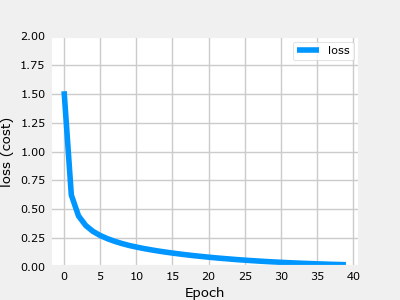

In [17]:
plot_loss_tf(history)

#### 预测 
要进行预测，使用Keras的`predict`。下面，X[1015]包含一张数字2的图像。

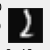

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
 predicting a Two: 
[[ -5.     1.     4.28   0.68 -10.77  -7.16  -3.21  -0.25  -8.04 -10.03]]
 Largest Prediction index: 2


In [18]:
image_of_two = X[1015]
display_digit(image_of_two)

prediction = model.predict(image_of_two.reshape(1,400))  # prediction

print(f" predicting a Two: \n{prediction}")
print(f" Largest Prediction index: {np.argmax(prediction)}")

最大输出为prediction[2]，表明预测的数字为“2”。如果问题仅要求进行选择，这样就足够了。使用NumPy的[argmax](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html)来选择它。如果问题需要一个概率，则需要使用softmax：

In [19]:
prediction_p = tf.nn.softmax(prediction)

print(f" predicting a Two. Probability vector: \n{prediction_p}")
print(f"Total of predictions: {np.sum(prediction_p):0.3f}")

 predicting a Two. Probability vector: 
[[8.65e-05 3.50e-02 9.29e-01 2.52e-02 2.70e-07 9.99e-06 5.16e-04 9.97e-03
  4.13e-06 5.66e-07]]
Total of predictions: 1.000


要返回一个表示预测目标的整数，你需要最大概率的索引。这可以通过Numpy的[argmax](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html)函数来实现。

In [20]:
yhat = np.argmax(prediction_p)

print(f"np.argmax(prediction_p): {yhat}")

np.argmax(prediction_p): 2


让我们对比一下64个随机数字样本的预测结果与标签。这需要运行一会儿。

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━

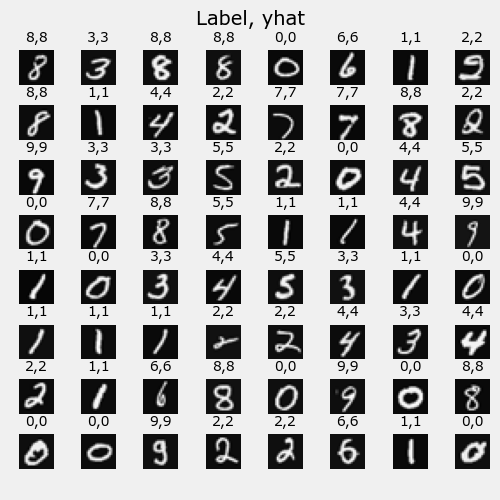

In [21]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# You do not need to modify anything in this cell

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(5,5))
fig.tight_layout(pad=0.13,rect=[0, 0.03, 1, 0.91]) #[left, bottom, right, top]
widgvis(fig)
for i,ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)
    
    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X[random_index].reshape((20,20)).T
    
    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')
    
    # Predict using the Neural Network
    prediction = model.predict(X[random_index].reshape(1,400))
    prediction_p = tf.nn.softmax(prediction)
    yhat = np.argmax(prediction_p)
    
    # Display the label above the image
    ax.set_title(f"{y[random_index,0]},{yhat}",fontsize=10)
    ax.set_axis_off()
fig.suptitle("Label, yhat", fontsize=14)
plt.show()

我们来看看其中一些错误。
>注意：增加训练轮数可以消除这个数据集上的错误。

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 345us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
7 errors out of 5000 images


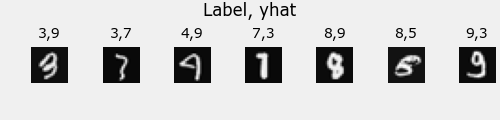

In [22]:
print( f"{display_errors(model,X,y)} errors out of {len(X)} images")

### 恭喜!
你已经成功构建并利用神经网络进行多类别分类。